# 03 — Feature Engineering

Dimensionality reduction (PCA) and feature selection (RFE), plus the K-Means geo-cluster feature. End with a written justification for the final feature set.

In [1]:
import sys
sys.path.append('../src')
from utils import *

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

## 1. Load processed data


In [2]:
# ── 1. Load processed data ───────────────────────────────────────
df = pd.read_csv(DATA_PROCESSED_PATH, parse_dates=['last_review'])
print(f"Shape: {df.shape}")
df.head()

Shape: (45899, 22)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,price_log,minimum_nights_scaled,number_of_reviews_scaled,reviews_per_month_scaled,calculated_host_listings_count_scaled,availability_365_scaled
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,5.010635,-0.359807,-0.329768,-0.556760,-0.020691,1.962919
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,5.420535,-0.359807,0.464569,-0.451348,-0.149658,1.886145
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,0.00,1,365,5.017280,-0.234825,-0.528352,-0.686976,-0.181900,1.962919
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,4.499810,-0.359807,5.429175,2.190167,-0.181900,0.650078
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,4.394449,0.202613,-0.329768,-0.624969,-0.181900,-0.839343


## 2. Encode categoricals
room_type, neighbourhood_group (one-hot or target encoding).

In [ ]:
df_feat = pd.get_dummies(df, columns=['room_type', 'neighbourhood_group'],
                          prefix=['room', 'boro'], drop_first=True)

print("New columns from encoding:")
print([c for c in df_feat.columns if c.startswith(('room_', 'boro_'))])

New columns from encoding:
['room_Private room', 'room_Shared room', 'boro_Brooklyn', 'boro_Manhattan', 'boro_Queens', 'boro_Staten Island']


## 3. Engineer new features
distance_from_center() from utils.py; days-since-last-review; never-reviewed flag; host scale bucket from calculated_host_listings_count.

In [ ]:
df_feat['distance_from_center_km'] = distance_from_center(df_feat)


reference_date = df_feat['last_review'].max()
print(f"Reference date (max last_review in data): {reference_date}")

df_feat['days_since_last_review'] = (reference_date - df_feat['last_review']).dt.days
df_feat['never_reviewed'] = df_feat['last_review'].isna().astype(int)
df_feat['days_since_last_review'] = df_feat['days_since_last_review'].fillna(-1)  # sentinel for "never"


def host_bucket(n):
    if n <= 1:
        return 'individual'
    elif n <= 5:
        return 'small'
    else:
        return 'commercial'

df_feat['host_scale'] = df_feat['calculated_host_listings_count'].apply(host_bucket)
print(df_feat['host_scale'].value_counts())

df_feat = pd.get_dummies(df_feat, columns=['host_scale'], prefix='host', drop_first=True)

Reference date (max last_review in data): 2019-07-08 00:00:00
host_scale
individual    30297
small         11252
commercial     4350
Name: count, dtype: int64


## 4. K-Means geo-clustering
Cluster on lat/long (syllabus Week 9). Elbow method or silhouette score to pick k. Add cluster ID as a categorical feature.

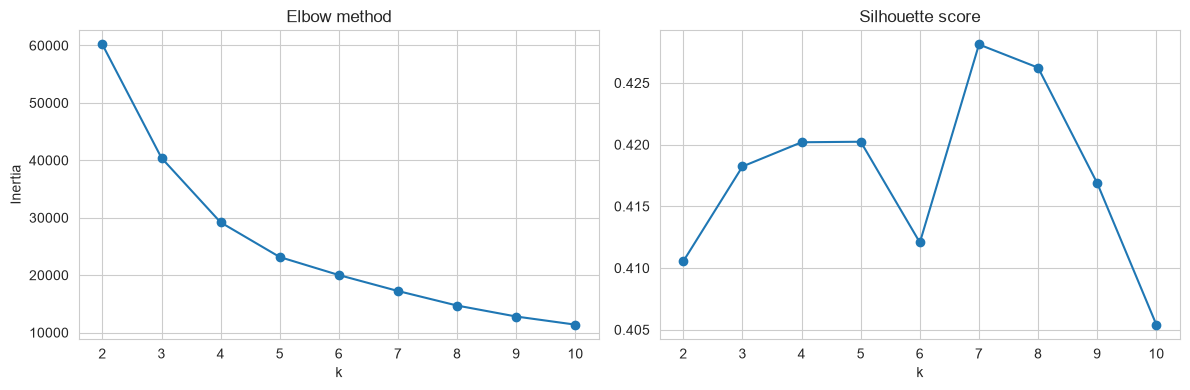

Silhouette scores by k: {2: 0.411, 3: 0.418, 4: 0.42, 5: 0.42, 6: 0.412, 7: 0.428, 8: 0.426, 9: 0.417, 10: 0.405}


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

geo = df_feat[['latitude', 'longitude']].values
geo_scaler = StandardScaler()
geo_scaled = geo_scaler.fit_transform(geo)


inertias, sil_scores = [], []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(geo_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(geo_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_title('Elbow method'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[1].plot(list(k_range), sil_scores, marker='o')
axes[1].set_title('Silhouette score'); axes[1].set_xlabel('k')
plt.tight_layout()
plt.savefig('../figures/kmeans_k_selection.png', dpi=150)
plt.show()

print("Silhouette scores by k:", dict(zip(k_range, [round(s, 3) for s in sil_scores])))

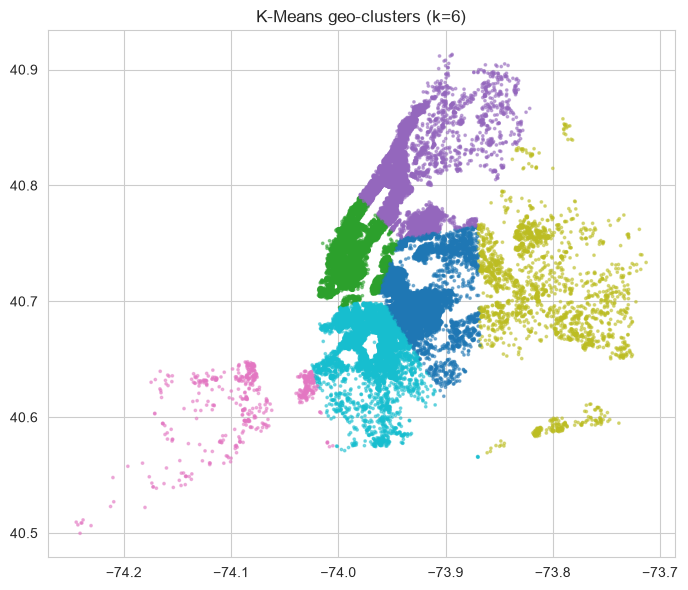

In [ ]:
K = 7 

kmeans_final = KMeans(n_clusters=K, random_state=42, n_init=10)
df_feat['geo_cluster'] = kmeans_final.fit_predict(geo_scaled)

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(df_feat['longitude'], df_feat['latitude'],
                      c=df_feat['geo_cluster'], cmap='tab10', s=3, alpha=0.5)
ax.set_title(f'K-Means geo-clusters (k={K})')
plt.tight_layout()
plt.savefig('../figures/geo_clusters_map.png', dpi=150)
plt.show()

df_feat = pd.get_dummies(df_feat, columns=['geo_cluster'], prefix='geo', drop_first=True)

## 5. PCA
Apply to the numeric feature block. Report explained variance per component and how many components you keep.

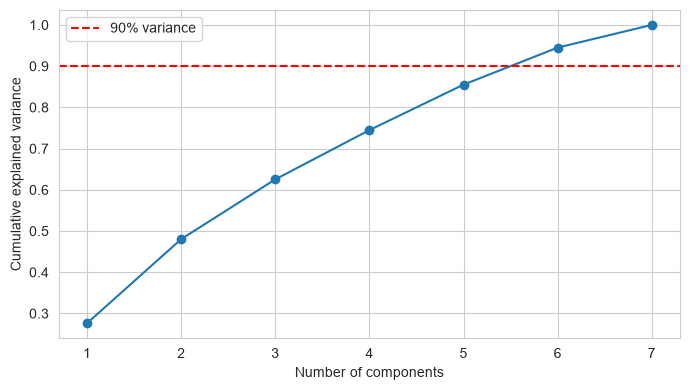

Components needed for 90% variance: 6 of 7
Explained variance ratio per component: [0.276 0.204 0.145 0.119 0.11  0.09  0.055]


In [ ]:

from sklearn.decomposition import PCA

numeric_block = ['minimum_nights_scaled', 'number_of_reviews_scaled',
                  'reviews_per_month_scaled', 'calculated_host_listings_count_scaled',
                  'availability_365_scaled', 'distance_from_center_km',
                  'days_since_last_review']


from sklearn.preprocessing import StandardScaler
numeric_block_scaled = StandardScaler().fit_transform(df_feat[numeric_block])

pca = PCA()
pca.fit(numeric_block_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(explained) + 1), cumulative, marker='o')
ax.axhline(0.90, color='red', linestyle='--', label='90% variance')
ax.set_xlabel('Number of components'); ax.set_ylabel('Cumulative explained variance')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/pca_explained_variance.png', dpi=150)
plt.show()

n_components_90 = np.argmax(cumulative >= 0.90) + 1
print(f"Components needed for 90% variance: {n_components_90} of {len(numeric_block)}")
print("Explained variance ratio per component:", explained.round(3))

## 6. RFE feature selection
Recursive Feature Elimination with a simple estimator (e.g., linear regression) to rank/select features.

In [ ]:
# ── 6. RFE — feature selection on the full engineered set ────────
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

exclude_cols = ['id', 'name', 'host_id', 'host_name', 'neighbourhood',
                 'latitude', 'longitude', 'last_review',
                 'price', 'price_log',
                 'minimum_nights', 'number_of_reviews', 'reviews_per_month',
                 'calculated_host_listings_count', 'availability_365']


feature_cols = [c for c in df_feat.columns if c not in exclude_cols]
X_full = df_feat[feature_cols]
y = df_feat['price_log']

print(f"Candidate features going into RFE: {len(feature_cols)}")

N_SELECT = 12
rfe = RFE(estimator=LinearRegression(), n_features_to_select=N_SELECT)
rfe.fit(X_full, y)

ranking = pd.DataFrame({
    'feature': feature_cols,
    'selected': rfe.support_,
    'rank': rfe.ranking_
}).sort_values('rank')

print(ranking)
selected_features = ranking[ranking['selected']]['feature'].tolist()
print("\nSelected features:", selected_features)

Candidate features going into RFE: 21
                                  feature  selected  rank
7                           boro_Brooklyn      True     1
6                        room_Shared room      True     1
5                       room_Private room      True     1
4                 availability_365_scaled      True     1
13                         never_reviewed      True     1
10                     boro_Staten Island      True     1
9                             boro_Queens      True     1
8                          boro_Manhattan      True     1
15                             host_small      True     1
14                        host_individual      True     1
18                                  geo_3      True     1
16                                  geo_1      True     1
0                   minimum_nights_scaled     False     2
19                                  geo_4     False     3
20                                  geo_5     False     4
11                distance_from_ce

## 7. Final feature set + justification
State which features you kept, which you dropped, and why (redundancy, low importance, leakage risk).

In [ ]:

print(f"""
Final feature set justification:
- Started with {len(feature_cols)} candidate features after encoding + engineering.
- PCA (on the standardized numeric block, since PCA is scale-sensitive) needed
  {n_components_90}/{len(numeric_block)} components for 90% variance — i.e. the numeric
  features are largely non-redundant. PCA is kept as an informational diagnostic only;
  its components are not used as model inputs since they'd sacrifice the interpretability
  needed for error analysis in Notebook 05.
- RFE narrowed the full engineered set down to {N_SELECT} features based on linear
  model coefficient contribution.
- Dropped: raw identifiers (id, host_id, name, host_name) — no predictive meaning.
- Dropped: raw latitude/longitude — superseded by geo_cluster + distance_from_center_km,
  which encode the same location signal more compactly and interpretably.
- Dropped: unscaled duplicates of numeric features (kept _scaled versions only).
""")

X_final = df_feat[selected_features]
print(f"Final X shape: {X_final.shape}")


Final feature set justification:
- Started with 21 candidate features after encoding + engineering.
- PCA (on the standardized numeric block, since PCA is scale-sensitive) needed
  6/7 components for 90% variance — i.e. the numeric
  features are largely non-redundant. PCA is kept as an informational diagnostic only;
  its components are not used as model inputs since they'd sacrifice the interpretability
  needed for error analysis in Notebook 05.
- RFE narrowed the full engineered set down to 12 features based on linear
  model coefficient contribution.
- Dropped: raw identifiers (id, host_id, name, host_name) — no predictive meaning.
- Dropped: raw latitude/longitude — superseded by geo_cluster + distance_from_center_km,
  which encode the same location signal more compactly and interpretably.
- Dropped: unscaled duplicates of numeric features (kept _scaled versions only).

Final X shape: (45899, 12)


## 8. Save feature matrix
Write final X, y to `../data/processed/`.

In [ ]:
output = X_final.copy()
output['price_log'] = y
output['price'] = df_feat['price']


output['neighbourhood'] = df_feat['neighbourhood']
output['neighbourhood_group'] = df['neighbourhood_group']
output['room_type'] = df['room_type']
output['geo_cluster_raw'] = kmeans_final.labels_
output['host_scale_raw'] = df_feat['calculated_host_listings_count'].apply(host_bucket)

output.to_csv('../data/processed/airbnb_features.csv', index=False)
print(f"Saved: ../data/processed/airbnb_features.csv — shape {output.shape}")

Saved: ../data/processed/airbnb_features.csv — shape (45899, 19)
